I tried to do it in a way, that only data_name can be changed in order to get visualizations for this dataset. But I haven't tested that yet:)

MAE was counted based on ground_truth calculated one time - probably not the best way to count it

In [1]:
import time
import numpy as np
import pandas as pd
import os
from tqdm import tqdm

from goodpoints import compress
from openxai.model import LoadModel
from openxai.dataloader import ReturnLoaders
import sage
import shap

np.random.seed(0)

data_name = 'german'
shap_values_cte_path = f'../metadata/{data_name}/cte_shap_sage_results_0_10.npy'
times_cte_info_path = f'../metadata/{data_name}/cte_shap_sage_times_0_10.csv'

shap_values_gt_path = f'../metadata/{data_name}/ground_truth_shap_sage_results_0_1.npy'
times_gt_info_path = f'../metadata/{data_name}/ground_truth_shap_sage_times_0_1.csv'

### load calculated shap and sage explanations data for 'ann' model

In [2]:
shap_values_cte = np.load(shap_values_cte_path, allow_pickle=True).item()
times_cte_info = pd.read_csv(times_cte_info_path)

###  load calculated "ground truth"

In [3]:
shap_values_gt = np.load(shap_values_gt_path, allow_pickle=True).item()
times_gt_info = pd.read_csv(times_gt_info_path)

### barplot MAE 

In [54]:
def metric_mae(x, y):
    return np.mean(np.abs(x-y))

In [55]:
columns = [ 'method', 'estimator', 'explanation', 'mae']
results = pd.DataFrame(columns=columns)

shap kernel

In [56]:
shap_values_gt_ = shap_values_gt['ground_truth_shap_kernel']
methods = ['cte_shap_kernel', 'cte_with_predictions_shap_kernel', 'cte_stratified_shap_kernel']

for method in methods:
    shap_values_cte_ = shap_values_cte[method]
    
    for i in shap_values_cte_:
        mae = metric_mae(i, shap_values_gt_)

        if method == 'cte_shap_kernel':
            method = 'cte'
        elif method == 'cte_with_predictions_shap_kernel':
            method = 'cte_predictions'
        elif method == 'cte_stratified_shap_kernel':
            method = 'cte_stratified'

        results = pd.concat([results, pd.DataFrame([[method, 'kernel', 'shap', mae]], columns=columns)], ignore_index=True)

shap permutation

In [57]:
shap_values_gt_ = shap_values_gt['ground_truth_shap_permutation']
methods = ['cte_shap_permutation', 'cte_with_predictions_shap_permutation', 'cte_stratified_shap_permutation']
for method in methods:
    shap_values_cte_ = shap_values_cte[method]

    for i in shap_values_cte_:
        mae = metric_mae(i, shap_values_gt_)

        if method == 'cte_shap_permutation':
            method = 'cte'
        elif method == 'cte_with_predictions_shap_permutation':
            method = 'cte_predictions'
        elif method == 'cte_stratified_shap_permutation':
            method = 'cte_stratified'
            
        results = pd.concat([results, pd.DataFrame([[method, 'permutation', 'shap', mae]], columns=columns)], ignore_index=True)

sage kernel

In [58]:
shap_values_gt_ = shap_values_gt['ground_truth_sage_kernel']
methods = ['cte_sage_kernel', 'cte_with_predictions_sage_kernel', 'cte_stratified_sage_kernel']
for method in methods:
    shap_values_cte_ = shap_values_cte[method]
    
    for i in shap_values_cte_:
        mae = metric_mae(i, shap_values_gt_)

        if method == 'cte_sage_kernel':
            method = 'cte'
        elif method == 'cte_with_predictions_sage_kernel':
            method = 'cte_predictions'
        elif method == 'cte_stratified_sage_kernel':
            method = 'cte_stratified'

        results = pd.concat([results, pd.DataFrame([[method, 'kernel', 'sage', mae]], columns=columns)], ignore_index=True)

sage permutation

In [59]:
shap_values_gt_ = shap_values_gt['ground_truth_sage_permutation']
methods = ['cte_sage_permutation', 'cte_with_predictions_sage_permutation', 'cte_stratified_sage_permutation']
for method in methods:
    shap_values_cte_ = shap_values_cte[method]

    for i in shap_values_cte_:
        mae = metric_mae(i, shap_values_gt_)
    
        if method == 'cte_sage_permutation':
            method = 'cte'
        elif method == 'cte_with_predictions_sage_permutation':
            method = 'cte_predictions'
        elif method == 'cte_stratified_sage_permutation':
            method = 'cte_stratified'

        results = pd.concat([results, pd.DataFrame([[method, 'permutation', 'sage', mae]], columns=columns)], ignore_index=True)

In [60]:
results

,method,estimator,explanation,mae
0,cte,kernel,shap,0.008477
1,cte,kernel,shap,0.008977
2,cte,kernel,shap,0.007308
3,cte,kernel,shap,0.009659
4,cte,kernel,shap,0.009072
...,...,...,...,...
115,cte_stratified,permutation,sage,0.006240
116,cte_stratified,permutation,sage,0.004733
117,cte_stratified,permutation,sage,0.007805
118,cte_stratified,permutation,sage,0.005732


In [61]:
results['exp_est'] = results['estimator'].str.capitalize() + results['explanation'].str.upper()


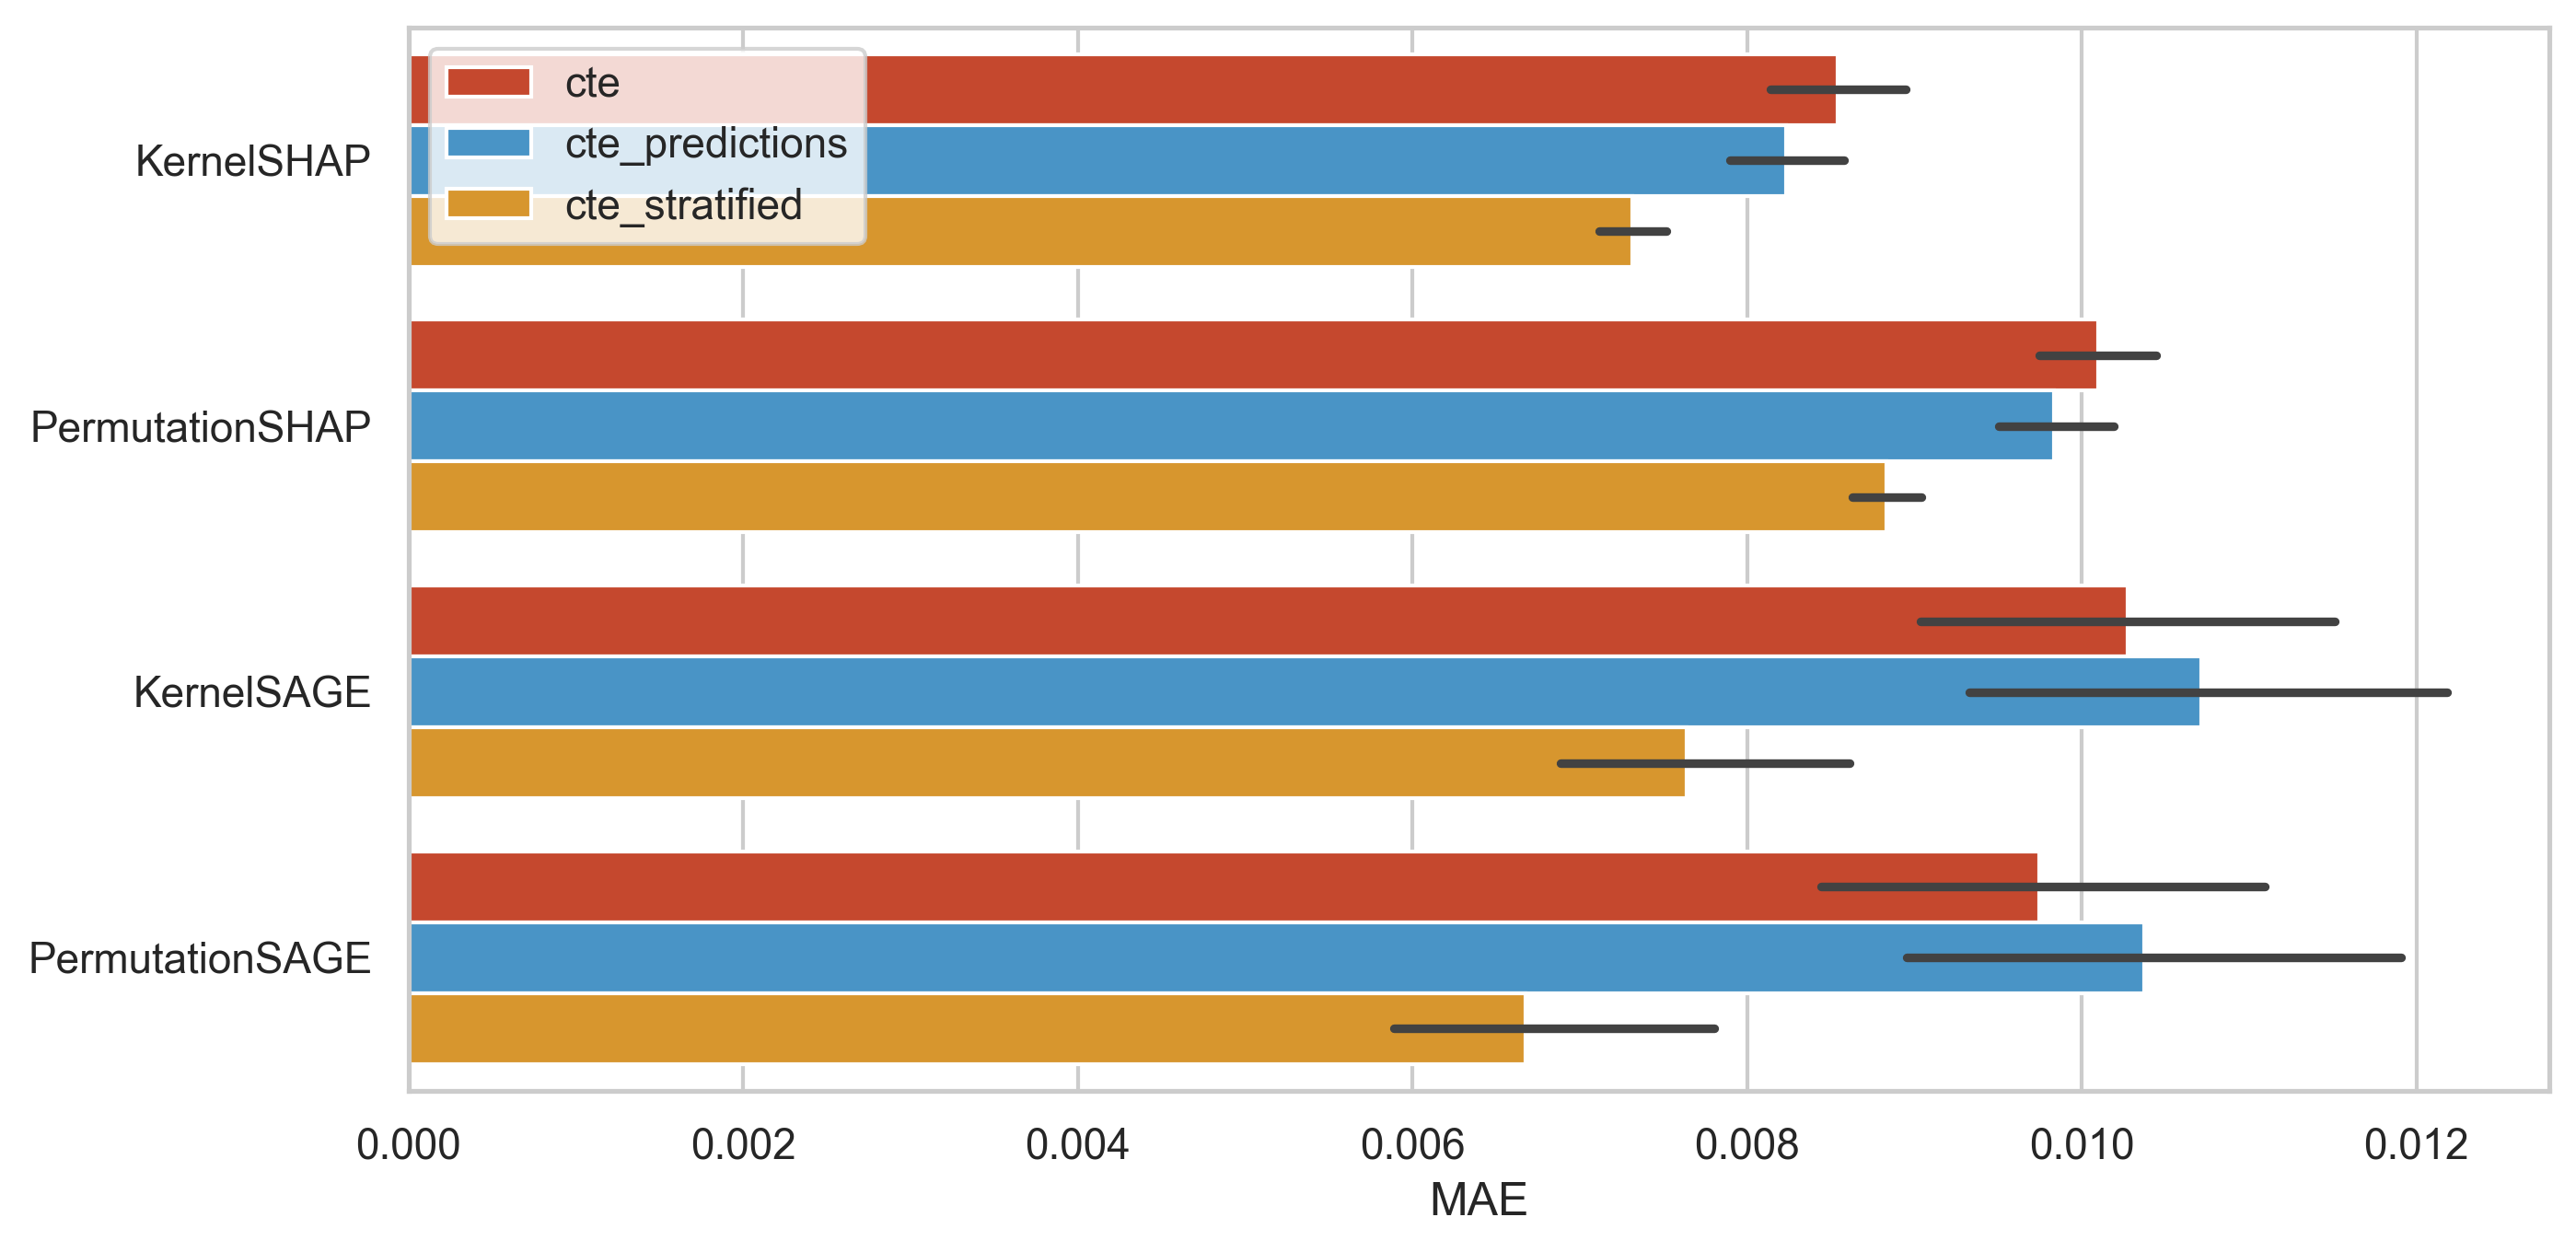

In [96]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5), dpi=300)
sns.barplot(y='exp_est', x='mae', hue='method', data=results, palette=['#DE3815', '#3498DB', '#F39C12'])

plt.legend(bbox_to_anchor=(0, 1), loc='upper left')
plt.ylabel("") 
plt.xlabel("MAE")
plt.show()
